In [98]:
from PIL import Image

In [112]:
!wget https://static-cse.canva.com/blob/1173240/screen3.jpg -O ifsp.png

--2025-04-30 22:49:36--  https://static-cse.canva.com/blob/1173240/screen3.jpg
Resolving static-cse.canva.com (static-cse.canva.com)... 104.16.103.112, 104.16.102.112, 2606:4700::6810:6770, ...
Connecting to static-cse.canva.com (static-cse.canva.com)|104.16.103.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 398980 (390K) [image/jpeg]
Saving to: ‘ifsp.png’

ifsp.png            100%[===================>] 389.63K  --.-KB/s    in 0.005s  

2025-04-30 22:49:36 (71.8 MB/s) - ‘ifsp.png’ saved [398980/398980]



In [113]:
from PIL import Image

ifsp = Image.open('ifsp.png')

In [114]:
import numpy as np

In [115]:
ifsp.size

(2640, 1485)

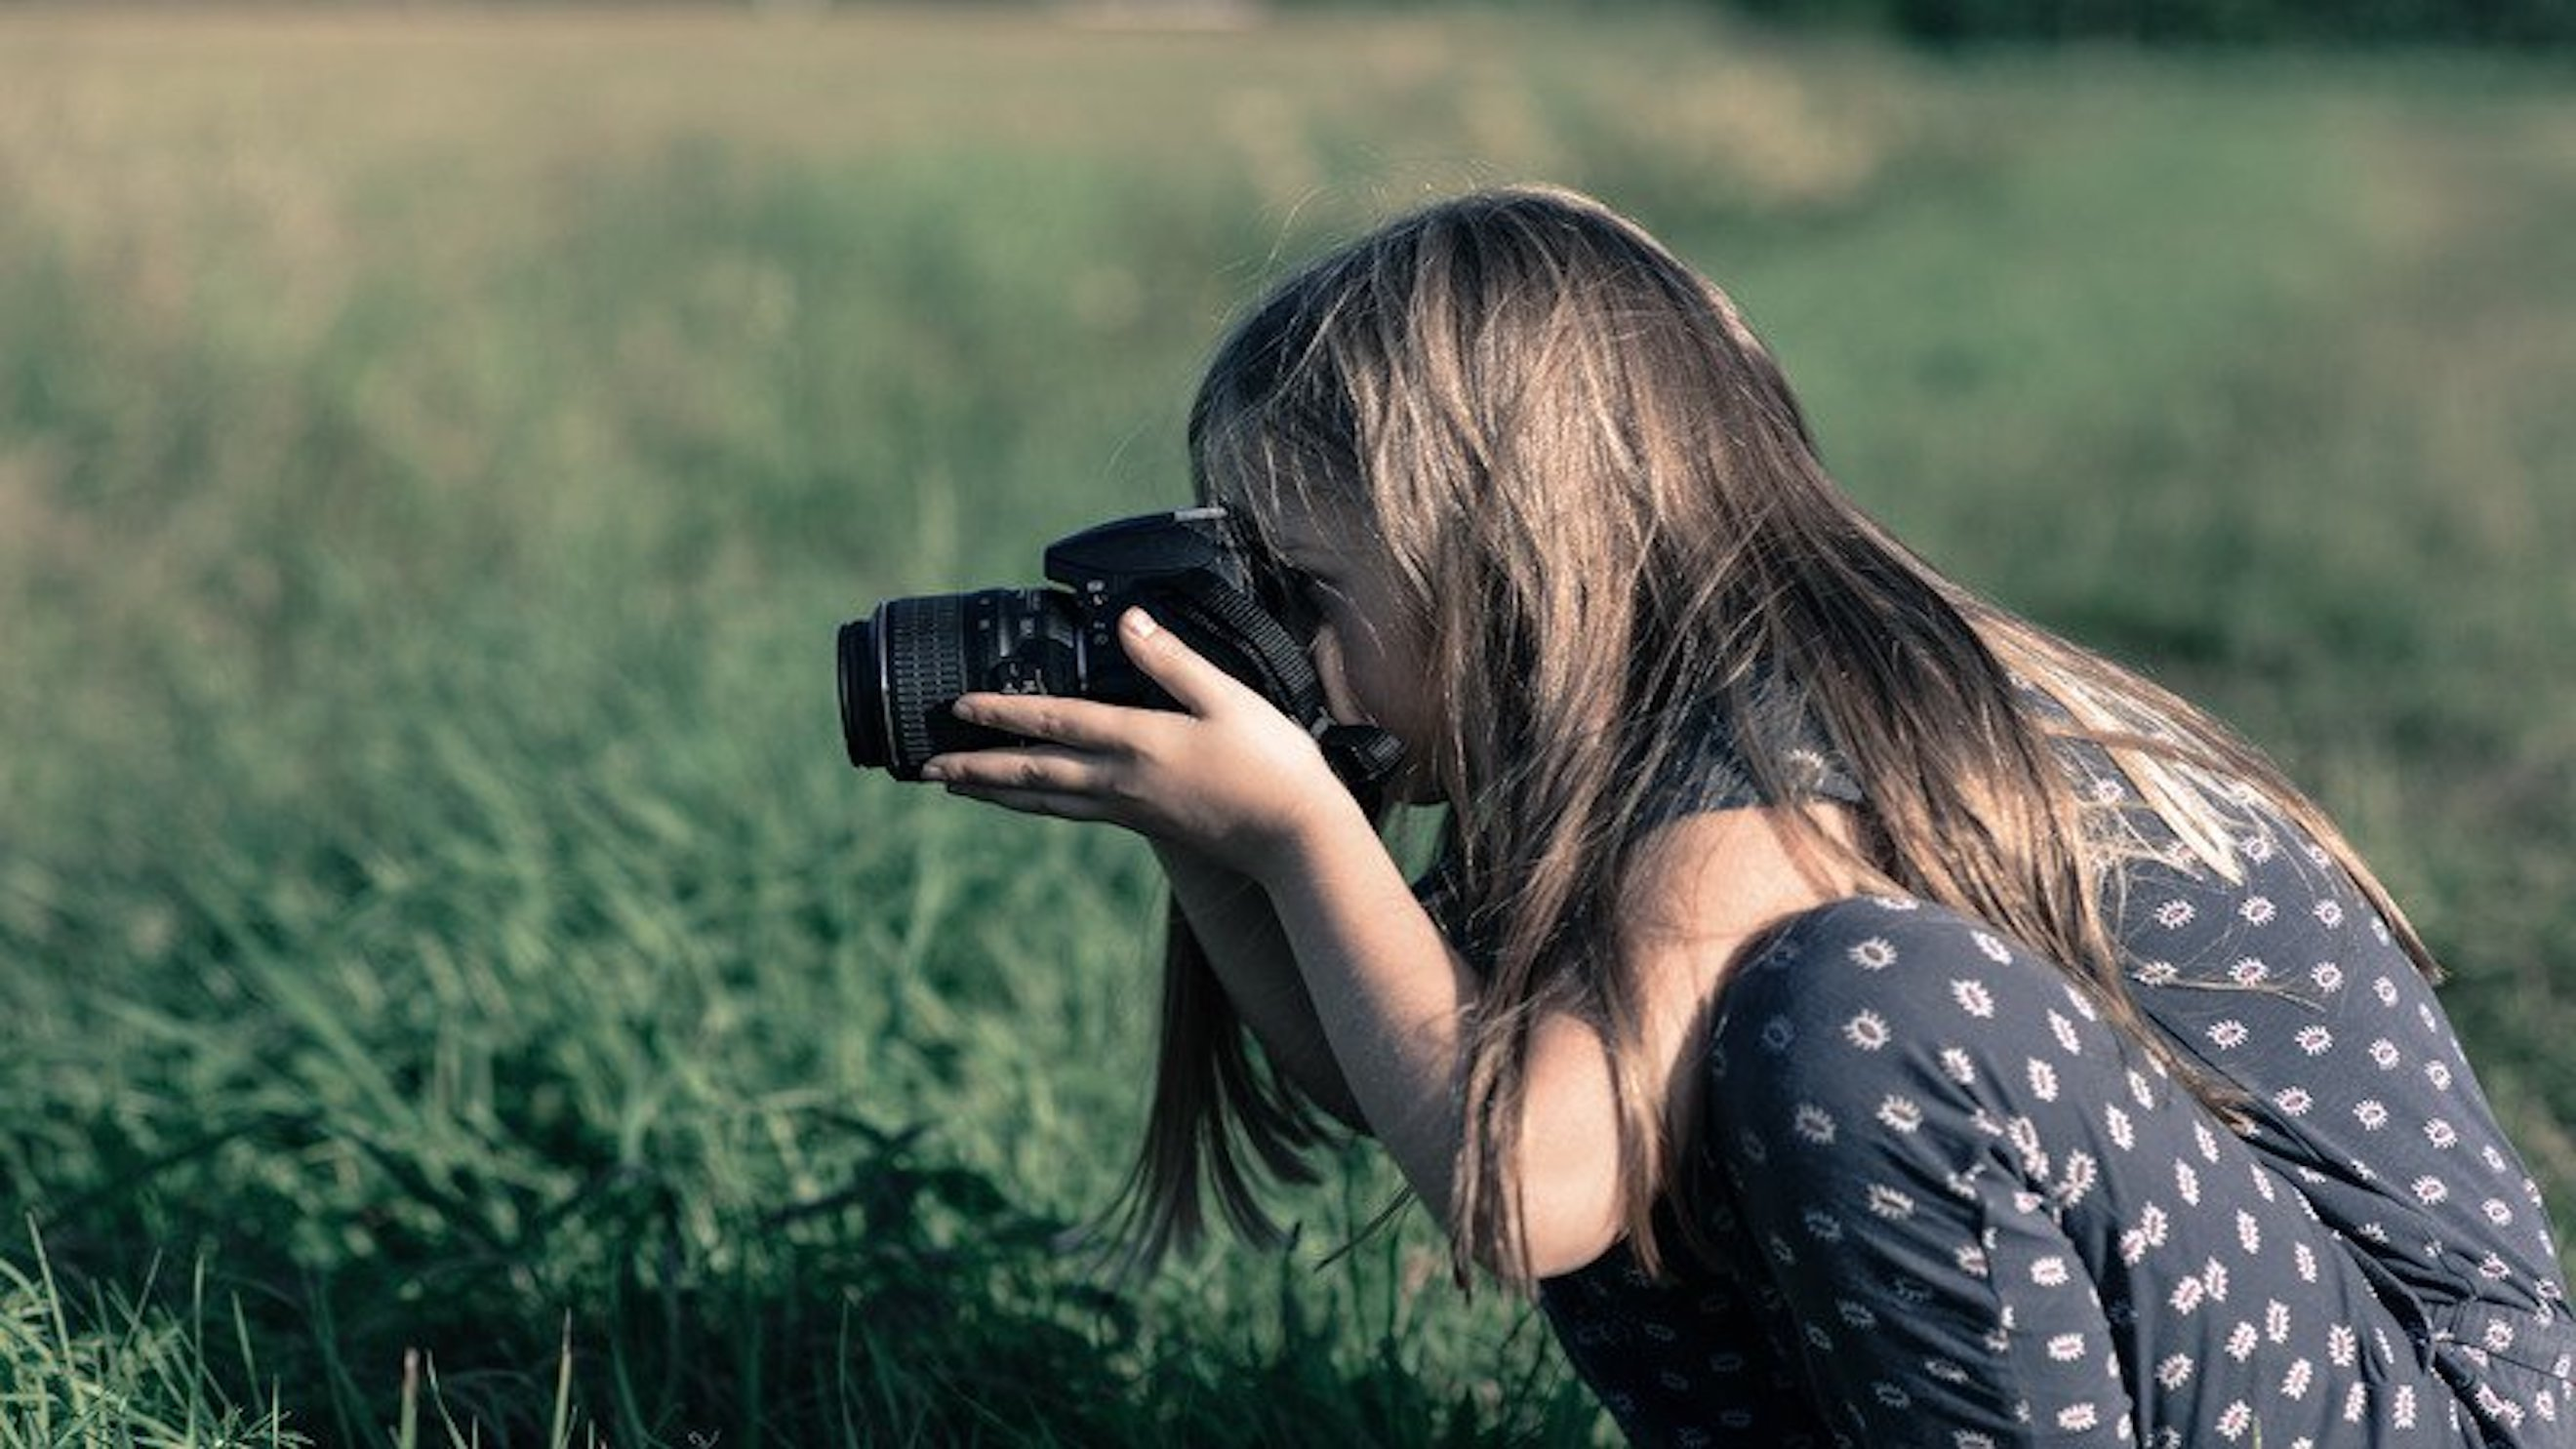

In [116]:
ifsp

In [119]:
redimensionado = ifsp.resize((100,70), resample=Image.BILINEAR)

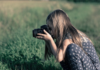

In [120]:
redimensionado

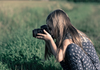

In [121]:
ifsp.resize((100,70), resample=Image.LANCZOS)

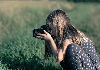

In [150]:
redimensionado_mais_proximo = ifsp.resize((100,70), resample=Image.NEAREST)
redimensionado_mais_proximo

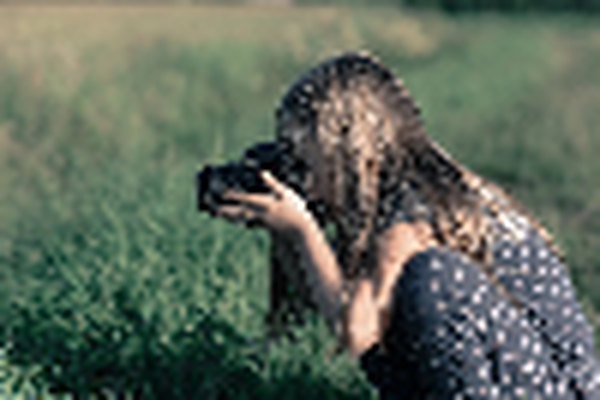

In [157]:
redimensionado_mais_proximo.resize((600, 400), resample=Image.LANCZOS)

In [125]:
orig_width, orig_height = ifsp.size
new_width, new_height = 10, 7


# Generate grid of pixel positions for the new image
new_x = np.linspace(0, new_width-1, new_width)
new_y = np.linspace(0, new_height-1, new_height)

# Create a meshgrid to combine new_x and new_y for plotting
new_x_grid, new_y_grid = np.meshgrid(new_x, new_y)

# Calculate the original pixel positions corresponding to the new ones
# Add 0.5 to ensure the pixel centers are used
orig_x = (new_x_grid + 0.5) * orig_width / new_width
orig_y = (new_y_grid + 0.5) * orig_height / new_height

# Flatten the arrays to make them compatible with scatter
orig_x_flat = orig_x.flatten()
orig_y_flat = orig_y.flatten()


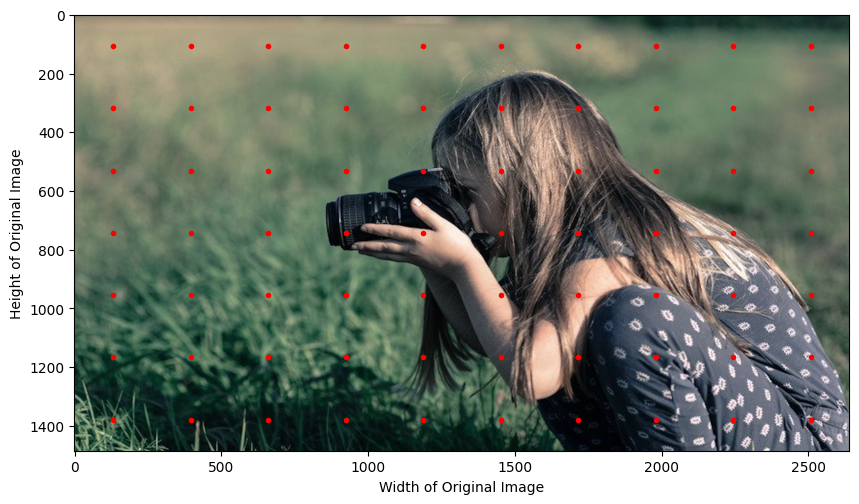

In [126]:
from matplotlib import pyplot as plt


# Create a plot
plt.figure(figsize=(10, 8))
plt.imshow(ifsp, alpha=1)  # Simulate the original image

# Plot the centers of the new pixels on the original image
plt.scatter(orig_x, orig_y, color='red', label='New pixel centers', marker='.')

plt.xlabel("Width of Original Image")
plt.ylabel("Height of Original Image")

# Show the plot
plt.show()

# Exemplo real

In [127]:
np.random.seed(42)
tamanho_original = 5
matriz_original = np.random.random_integers(0, 255, size=(tamanho_original, tamanho_original))
matriz_original

<ipython-input-127-02133c32e7ab>:3: DeprecationWarning: This function is deprecated. Please call randint(0, 255 + 1) instead
  matriz_original = np.random.random_integers(0, 255, size=(tamanho_original, tamanho_original))


array([[102, 179,  92,  14, 106],
       [ 71, 188,  20, 102, 121],
       [210, 214,  74, 202,  87],
       [116,  99, 103, 151, 130],
       [149,  52,   1,  87, 235]])

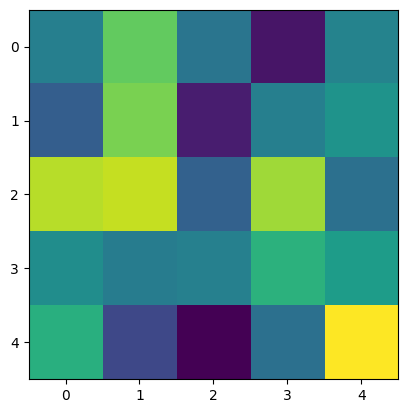

In [128]:
plt.imshow(matriz_original)

In [130]:
# Novas posicoes para matriz
tamanho_matriz = 3

espacamento = (tamanho_original - 1) / tamanho_matriz
inicio = espacamento / 2
fim = espacamento * tamanho_matriz

pontos = np.arange(inicio, fim, espacamento)
pontos

array([0.66666667, 2.        , 3.33333333])

In [131]:
x, y = np.meshgrid(pontos, pontos)

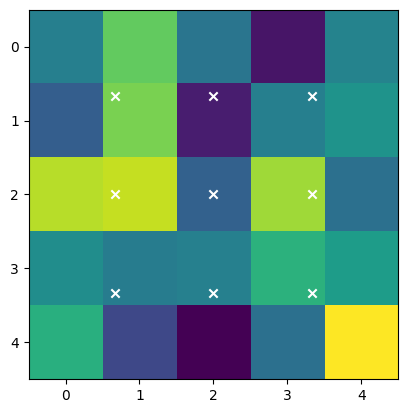

In [133]:
plt.imshow(matriz_original)
plt.scatter(x, y, color='white', marker='x')

In [134]:
m0 = matriz_original[np.floor(y).astype(int), np.floor(x).astype(int)]
m0

array([[102,  92,  14],
       [210,  74, 202],
       [116, 103, 151]])

In [135]:
m1 = matriz_original[np.ceil(y).astype(int), np.floor(x).astype(int)]
m1

array([[ 71,  20, 102],
       [210,  74, 202],
       [149,   1,  87]])

In [136]:
m2 = matriz_original[np.floor(y).astype(int), np.ceil(x).astype(int)]
m2

array([[179,  92, 106],
       [214,  74,  87],
       [ 99, 103, 130]])

In [137]:
m3 = matriz_original[np.ceil(x).astype(int), np.ceil(y).astype(int)]
m3

array([[188, 214,  52],
       [ 20,  74,   1],
       [121,  87, 235]])

In [138]:
htop = m0 + (m1 - m0) * (y - np.floor(y))
htop

array([[ 81.33333333,  44.        ,  72.66666667],
       [210.        ,  74.        , 202.        ],
       [127.        ,  69.        , 129.66666667]])

In [ ]:
hbot = m2 + (m3 - m2) * (x - np.floor(x))
hbot

array([[185.        ,  92.        ,  88.        ],
       [ 84.66666667,  74.        ,  58.33333333],
       [113.66666667, 103.        , 165.        ]])

In [143]:
output = htop + (hbot - htop) * (x - np.floor(x))
output

array([[150.44444444,  44.        ,  77.77777778],
       [126.44444444,  74.        , 154.11111111],
       [118.11111111,  69.        , 141.44444444]])

In [144]:
matriz_original

array([[102, 179,  92,  14, 106],
       [ 71, 188,  20, 102, 121],
       [210, 214,  74, 202,  87],
       [116,  99, 103, 151, 130],
       [149,  52,   1,  87, 235]])

In [147]:
maximo = np.max(matriz_original)
minimo = np.min(matriz_original)

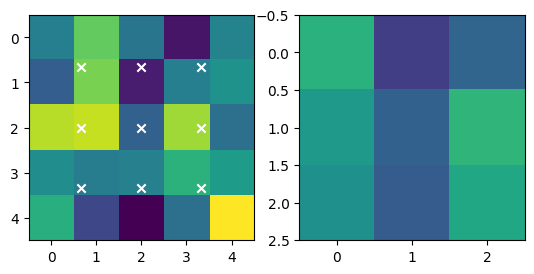

In [148]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(matriz_original)
ax[0].scatter(x, y, color='white', marker='x')

ax[1].imshow(output, vmin = minimo, vmax = maximo)